<a href="https://colab.research.google.com/github/Kommandjsdf/MachineLearning/blob/main/NLTK/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
!pip install nltk

In [71]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('movie_reviews')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

In [72]:
from nltk.corpus import movie_reviews
import random

documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

random.shuffle(documents)

In [73]:
print(documents[10])

(['capsule', ':', 'a', 'science', 'fiction', 'allegory', '.', 'at', 'the', 'millennium', 'a', 'lethal', 'contagious', 'virus', 'has', 'hit', 'taiwan', '.', 'officials', 'have', 'cut', 'off', 'water', 'and', 'other', 'services', 'to', 'the', 'center', 'of', 'contagion', '.', 'life', 'there', 'devolves', 'and', 'degenerates', '.', 'a', 'man', 'in', 'an', 'apartment', 'has', 'a', 'hole', 'in', 'his', 'floor', 'and', 'with', 'it', 'harasses', 'his', 'downstairs', 'neighbor', '.', 'a', 'slow', 'but', 'harrowing', 'film', 'to', 'be', 'missed', 'if', 'possible', '.', ',', 'low', '-', '1', '(', '-', '4', 'to', '+', '4', ')', '-', 'the', 'taiwan', 'virus', 'is', 'ravaging', 'taiwan', 'and', 'the', 'part', 'of', 'the', 'city', 'that', 'is', 'the', 'center', 'of', 'the', 'contagion', 'has', 'been', 'evacuated', 'of', 'anyone', 'who', 'will', 'go', '.', 'one', 'apartment', 'building', 'still', 'houses', 'people', '.', 'a', 'woman', ',', 'formerly', 'an', 'office', 'worker', ',', '(', 'yang', 'kuei

In [74]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def clear_word(words: list) -> list:
  return [ps.stem(w.lower()) for w in words if w.isalpha() and w.lower() not in stop_words]

In [75]:
print(stop_words)

{"won't", "she'd", 'too', 'hadn', 'm', 'very', 'to', 'she', 's', 'were', 'can', 'before', 'had', 'shan', "we'd", "wasn't", 'against', 'when', 'more', 'won', 'weren', "you're", 'if', 'into', 'my', 'hasn', 'its', 'where', 'at', 'being', 'while', 'theirs', 'll', 'these', 'your', "i'll", 'again', 't', 'whom', "that'll", 'isn', "doesn't", 'our', 'then', 'and', 'who', 'than', 'that', 'from', 'but', 'now', "we'll", 'don', "don't", 'own', 'd', 'himself', 'itself', 'for', 'all', "they're", 'over', "they'd", 'this', 'once', 'y', "couldn't", "mustn't", 'by', 'nor', 'be', "should've", 'some', "hadn't", 'you', 'an', 'below', 'under', 'aren', 'because', 'through', 'after', 'ain', "shan't", "you'd", 'we', 'of', 'or', 'mustn', 'off', 'doing', 'ma', 'his', 'should', "he's", 'just', 'how', 'during', 'only', 'is', 'up', 'so', 'what', 'their', 'wasn', 'those', 'couldn', 'until', 'on', "he'd", 'ourselves', "aren't", 'themselves', 'a', 'having', "i'm", "he'll", "it's", "they've", "isn't", "mightn't", 'here'

In [76]:
cleaned_document = [(" ".join(clear_word(document)), category) for document, category in documents]

In [77]:
print(cleaned_document[10])

('capsul scienc fiction allegori millennium lethal contagi viru hit taiwan offici cut water servic center contagion life devolv degener man apart hole floor harass downstair neighbor slow harrow film miss possibl low taiwan viru ravag taiwan part citi center contagion evacu anyon go one apart build still hous peopl woman formerli offic worker yang kuei mei torment upstair neighbor lee kang sheng hole cut plumber floor use drain neighbor run small fail groceri store make thing depress constantli rain hard upstair neighbor vomit pour water etc small almost entir one side war start allegori callous selfish woman live pile roll toilet tissu incongru song ad show downstair neighbor dream song popular taiwanes singer grace chang apart fall apart wallpap separ wall plumb fail boredom shown long cut noth happen lot film seem use stori might done much better ten minut anim film star consid great dramat actor one review film seem longer minut two hour film', 'neg')


In [78]:
df = pd.DataFrame(cleaned_document, columns=('Review', 'Label'))
df.head(11)

,Review,Label
0,frank detorri bill murray singl dad live beer ...,neg
1,bruce willi star malcolm award win child psych...,pos
2,man present us henri portrait serial killer co...,pos
3,year captain leo davidson mark wahlberg boogi ...,neg
4,wake smash success rumbl bronx look like jacki...,pos
5,tire hot new releas gone time get video store ...,pos
6,releas dolor claiborn wide releas weekend add ...,pos
7,indian runner courier becam messag carri dange...,pos
8,rememb see trailer black cauldron pinocchio vi...,pos
9,wesley snipe master select bad action role mur...,neg


<Axes: xlabel='Label'>

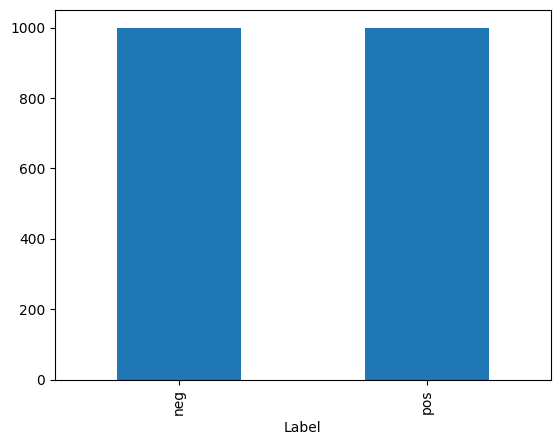

In [79]:
df['Label'].value_counts().plot(kind='bar')

In [80]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Review'])
y = df['Label']

In [81]:
print(X)
print(y)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 501022 stored elements and shape (2000, 25258)>
  Coords	Values
  (0, 8178)	5
  (0, 5559)	1
  (0, 2015)	2
  (0, 14700)	2
  (0, 20129)	1
  (0, 5037)	1
  (0, 12834)	2
  (0, 1759)	1
  (0, 11686)	1
  (0, 8023)	1
  (0, 836)	1
  (0, 23304)	1
  (0, 19093)	1
  (0, 10498)	1
  (0, 14617)	1
  (0, 5857)	1
  (0, 17180)	1
  (0, 5170)	1
  (0, 19760)	2
  (0, 6654)	1
  (0, 8188)	1
  (0, 23763)	1
  (0, 19499)	1
  (0, 18869)	1
  (0, 18385)	1
  :	:
  (1999, 2397)	1
  (1999, 1494)	1
  (1999, 18475)	1
  (1999, 268)	1
  (1999, 9873)	3
  (1999, 23614)	1
  (1999, 5496)	1
  (1999, 20547)	1
  (1999, 16914)	2
  (1999, 2617)	1
  (1999, 25049)	1
  (1999, 9624)	1
  (1999, 4353)	1
  (1999, 23351)	1
  (1999, 15660)	1
  (1999, 24436)	2
  (1999, 9106)	3
  (1999, 1752)	2
  (1999, 22478)	1
  (1999, 16751)	1
  (1999, 22723)	1
  (1999, 13870)	1
  (1999, 1581)	1
  (1999, 22101)	1
  (1999, 7339)	2
0       neg
1       pos
2       pos
3       neg
4       pos
       ...

In [133]:
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# model = LogisticRegression(max_iter=1000)
model = MultinomialNB()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [126]:
from sklearn.metrics import accuracy_score, confusion_matrix

print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.865


Text(0.5, 1.0, 'Confusion Matrix')

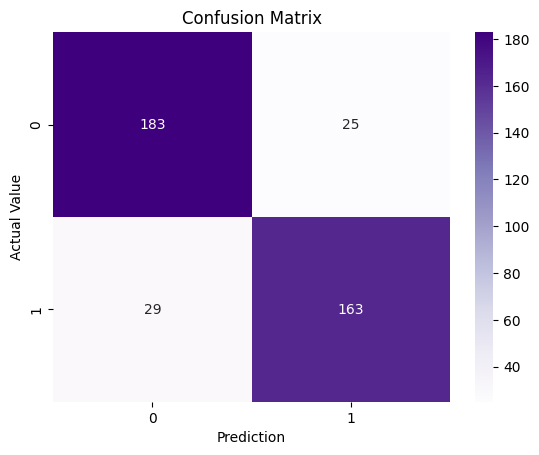

In [127]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.xlabel('Prediction')
plt.ylabel('Actual Value')
plt.title('Confusion Matrix')

In [134]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [135]:
def predict_review(text: str) -> str:
  cleaned = " ".join(clear_word(word_tokenize(text)))
  vec = vectorizer.transform([cleaned])
  return model.predict(vec)[0]

In [136]:
print(predict_review("I like the movie!"))
print(predict_review("The story was pretty bad, but everything else was actually good. Good movie just as a movie, but they could've spent the money making a movie about something else"))
print(predict_review("I really enjoyed the movie's good vibe"))
print(predict_review("The movie is talked about so much for a reason. You definitely won't regret watching this"))
print(predict_review("Watching this is a waste of time if you ask me. Only watch this if you're a big fan of the actually good book"))
print(predict_review("I wish they made the music better, but I wouldn't say the movie is bad. Very calm and relaxing, especially when watching after a hard day"))
print(predict_review("Nothing particularly wrong with this movie, the hate is forced on my opinion. I personally liked it, and the acting isn't as bad as everyone says"))
print(predict_review("It's a shame I can't watch this for the first time again, nothing will ever match that feeling. If you haven't watched this, you're missing out"))
print(predict_review("Don't watch this if you don't like fiction - you'll just hate it. Everything is very unrealistic and made-up. The actors, the script, the scenes, and almost everything else was actually good!"))
print(predict_review("The movie is awesome if you're looking for a way to waste your time"))

neg
neg
pos
pos
neg
neg
neg
pos
neg
neg


| Review | Naive Bayes | Logistic Regression | Actual |
| -- | -- | -- | -- |
| I like the movie! | neg | neg | pos |
| The story was pretty bad, but everything else was actually good. Good movie just as a movie, but they could've spent the money making a movie about something else | neg | neg | pos |
| I really enjoyed the movie's good vibe | pos | neg | pos |
| The movie is talked about so much for a reason. You definitely won't regret watching this | pos | neg | pos |
| Watching this is a waste of time if you ask me. Only watch this if you're a big fan of the actually good book | neg | neg | neg |
| I wish they made the music better, but I wouldn't say the movie is bad. Very calm and relaxing, especially when watching after a hard day | neg | neg | pos |
| Nothing particularly wrong with this movie, the hate is forced on my opinion. I personally liked it, and the acting isn't as bad as everyone says | neg | neg | pos |
| It's a shame I can't watch this for the first time again, nothing will ever match that feeling. If you haven't watched this, you're missing out | neg | neg | pos |
| Don't watch this if you don't like fiction - you'll just hate it. Everything is very unrealistic and made-up. The actors, the script, the scenes, and almost everything else was actually good! | neg | neg | pos |
| The movie is awesome if you're looking for a way to waste your time | neg | neg | neg |